This notebook performs an initial exploration of stock price data for **30 companies** (2010–2026).

Historical data was downloaded and data integrity was validated by checking:

- absence of null values  
- correct data types  
- ordered dates  
- detection of temporal gaps  
- absence of negative values  

Finally, the temporal range of existence for each asset was analyzed to establish a **dynamic universe of stocks**.


In [11]:
# imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

sys.path.append(os.path.abspath(".."))
from src.data.download_data import DownloadData

import pandas_market_calendars as mcal





In [124]:
# download data
tickers = [
    # Technology
    "AAPL", "MSFT", "NVDA", "GOOG", "META", "AVGO",

    # Consumer Discretionary
    "AMZN", "HD", "MCD", "NKE",

    # Health
    "JNJ", "UNH", "PFE", "ABBV",

    # Industrials
    "CAT", "BA", "UPS", "MMM",

    # Energy
    "XOM", "CVX", "SLB",

    # Financials
    "JPM", "BAC", "GS", "MS",

    # Utilities / Materials
    "NEE", "LIN", "DOW",

    # Telecom / Communications
    "VZ", "CMCSA"
]

dd = DownloadData(tickers)
dd.download_tick_data()

dfs = {
    tick:pd.read_csv(os.path.join("/Users/jaime/Documents/UPM/TFG/data/raw/",csv), header=[0,1], index_col=0)
    for tick,csv in zip(sorted(tickers),sorted(os.listdir("/Users/jaime/Documents/UPM/TFG/data/raw/")))
    if csv != "GSPC.csv"}



[*********************100%***********************]  1 of 1 completed

 Descargando AAPL
 Descargando MSFT



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

 Descargando NVDA
 Descargando GOOG
 Descargando META
 Descargando AVGO



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


...

 Descargando SLB
 Descargando JPM
 Descargando BAC
 Descargando GS



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


 Descargando MS
 Descargando NEE
 Descargando LIN
 Descargando DOW
 Descargando VZ


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


 Descargando CMCSA

Descarga completada.


In [108]:
# view data

df = pd.read_csv("/Users/jaime/Documents/UPM/TFG/data/raw/AAPL.csv", header=[0,1], index_col=0)

df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.412384,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.423471,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.321295,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.309610,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.351558,7.570714,7.571429,7.466429,7.510714,447610800


In [109]:
# need to drop the Ticker row and clean the df for better visualization
df = df.droplevel(1,axis=1)
df.columns.name = None
df.head()


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.412384,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.423471,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.321295,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.309610,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.351558,7.570714,7.571429,7.466429,7.510714,447610800


In [ ]:
# check for null values
df.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [110]:
# check if there are any missing data gaps in any of the 30 assets
for ticker,df in dfs.items():
    print(f"{ticker}: {df.isna().sum().sum() == 0}")

AAPL: True
ABBV: True
AMZN: True
AVGO: True
BA: True
BAC: True
CAT: True
CMCSA: True
CVX: True
DOW: True
GOOG: True
GS: True
HD: True
JNJ: True
JPM: True
LIN: True
MCD: True
META: True
MMM: True
MS: True
MSFT: True
NEE: True
NKE: True
NVDA: True
PFE: True
SLB: True
UNH: True
UPS: True
VZ: True
XOM: True


In [114]:
# data is complete
# check that the data type for all dfs is correct

expected_types = {
    'Open': 'float64',
    'High': 'float64',
    'Low': 'float64',
    'Close': 'float64',
    'Adj Close': 'float64',
    'Volume': 'int64'
}

for ticker,df in dfs.items():
    df = df.droplevel(1,axis=1)
    df.columns.name = None
    for col, expected in expected_types.items():
        if df[col].dtype != expected:
                print(f"{ticker}: {col} incorrect dtype: {df[col].dtype} (expected: {expected})")




In [ ]:
# data type is correct
# check if dates are ordered in chronological order


for ticker,df in dfs.items():
    is_sorted = df.index.is_monotonic_increasing
    print(f"{ticker}: Ordered dates: {is_sorted}")


AAPL: Fechas ordenadas: True
ABBV: Fechas ordenadas: True
AMZN: Fechas ordenadas: True
AVGO: Fechas ordenadas: True
BA: Fechas ordenadas: True
BAC: Fechas ordenadas: True
CAT: Fechas ordenadas: True
CMCSA: Fechas ordenadas: True
CVX: Fechas ordenadas: True
DOW: Fechas ordenadas: True
GOOG: Fechas ordenadas: True
GS: Fechas ordenadas: True
HD: Fechas ordenadas: True
JNJ: Fechas ordenadas: True
JPM: Fechas ordenadas: True
LIN: Fechas ordenadas: True
MCD: Fechas ordenadas: True
META: Fechas ordenadas: True
MMM: Fechas ordenadas: True
MS: Fechas ordenadas: True
MSFT: Fechas ordenadas: True
NEE: Fechas ordenadas: True
NKE: Fechas ordenadas: True
NVDA: Fechas ordenadas: True
PFE: Fechas ordenadas: True
SLB: Fechas ordenadas: True
UNH: Fechas ordenadas: True
UPS: Fechas ordenadas: True
VZ: Fechas ordenadas: True
XOM: Fechas ordenadas: True


In [113]:
# dates are ordered
# are there temporal gaps?

start = "2010-01-01"
end = "2026-02-01"


nyse = mcal.get_calendar('NYSE')
schedule = nyse.schedule(start_date=start, end_date=end)
expected_days = mcal.date_range(schedule, frequency='1D')
expected_days = expected_days.normalize().tz_localize(None)

for ticker,df in dfs.items():
    df.index = pd.to_datetime(df.index, utc=True)
    df_days = df.index.normalize().tz_localize(None)
    missing_days = expected_days.difference(df_days)
    extra_days = df_days.difference(expected_days)
    duplicates = df.index[df.index.duplicated()]
    print(f"{ticker}: Missing days: ", missing_days)
    print(f"{ticker}: Extra days: ", extra_days)
    print(f"{ticker}: Duplicates: ",duplicates)
    

AAPL: Missing days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
AAPL: Extra days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
AAPL: Duplicates:  DatetimeIndex([], dtype='datetime64[ns, UTC]', name='Date', freq=None)
ABBV: Missing days:  DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2012-12-17', '2012-12-18', '2012-12-19', '2012-12-20',
               '2012-12-21', '2012-12-24', '2012-12-26', '2012-12-27',
               '2012-12-28', '2012-12-31'],
              dtype='datetime64[ns]', length=754, freq=None)
ABBV: Extra days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
ABBV: Duplicates:  DatetimeIndex([], dtype='datetime64[ns, UTC]', name='Date', freq=None)
AMZN: Missing days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
AMZN: Extra days:  DatetimeIndex([], dtype='datetime64[n

In [115]:
# there are no temporal gaps, for assets incorporated late we use a dynamic universe of stocks

# check if there are any negative values in the dfs


for ticker,df in dfs.items():
    print(f"{ticker}: ", (df < 0).any())


AAPL:  Price      Ticker
Adj Close  AAPL      False
Close      AAPL      False
High       AAPL      False
Low        AAPL      False
Open       AAPL      False
Volume     AAPL      False
dtype: bool
ABBV:  Price      Ticker
Adj Close  ABBV      False
Close      ABBV      False
High       ABBV      False
Low        ABBV      False
Open       ABBV      False
Volume     ABBV      False
dtype: bool
AMZN:  Price      Ticker
Adj Close  AMZN      False
Close      AMZN      False
High       AMZN      False
Low        AMZN      False
Open       AMZN      False
Volume     AMZN      False
dtype: bool
AVGO:  Price      Ticker
Adj Close  AVGO      False
Close      AVGO      False
High       AVGO      False
Low        AVGO      False
Open       AVGO      False
Volume     AVGO      False
dtype: bool
BA:  Price      Ticker
Adj Close  BA        False
Close      BA        False
High       BA        False
Low        BA        False
Open       BA        False
Volume     BA        False
dtype: bool
BAC:  P

In [116]:
# there are no negative values
# let's look at basic statistics of some assets

# calculate for each asset its temporal existence range
for ticker,df in dfs.items():
    df.index = df.index.normalize().tz_localize(None)
    start = df.index[0]
    end = df.index[len(df.index)-1]
    print(f"{ticker}: {start} - {end}")

AAPL: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
ABBV: 2013-01-02 00:00:00 - 2026-01-30 00:00:00
AMZN: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
AVGO: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
BA: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
BAC: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
CAT: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
CMCSA: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
CVX: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
DOW: 2019-03-20 00:00:00 - 2026-01-30 00:00:00
GOOG: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
GS: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
HD: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
JNJ: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
JPM: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
LIN: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
MCD: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
META: 2012-05-18 00:00:00 - 2026-01-30 00:00:00
MMM: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
MS: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
MSFT: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
NEE: 201

In [117]:
# check which assets are incorporated late and at what date

start_actual = pd.Timestamp('2010-01-04 00:00:00')

for ticker,df in dfs.items():
    df.index = df.index.normalize().tz_localize(None)
    start = df.index[0]
    if start != start_actual:
        print(f"{ticker}: {start}")


ABBV: 2013-01-02 00:00:00
DOW: 2019-03-20 00:00:00
META: 2012-05-18 00:00:00


In [ ]:
# calculate mean, median, minimum and maximum, etc

for ticker, df in dfs.items():
    print("\n" + "="*60)
    print(f"Estadísticas para {ticker}")
    print("="*60)
    print(df.describe().round(3)) 




Estadísticas para AAPL
Price  Adj Close     Close      High       Low      Open        Volume
Ticker      AAPL      AAPL      AAPL      AAPL      AAPL          AAPL
count   4044.000  4044.000  4044.000  4044.000  4044.000  4.044000e+03
mean      78.328    80.734    81.534    79.863    80.672  2.181747e+08
std       75.835    75.560    76.296    74.750    75.487  2.152739e+08
min        5.754     6.859     7.000     6.795     6.870  1.791060e+07
25%       18.275    21.591    21.720    21.370    21.533  7.703408e+07
50%       39.250    41.701    42.240    41.228    41.684  1.302068e+08
75%      143.472   146.513   147.978   145.020   146.245  2.889565e+08
max      285.922   286.190   288.620   283.300   286.200  1.880998e+09

Estadísticas para ABBV
Price  Adj Close     Close      High       Low      Open        Volume
Ticker      ABBV      ABBV      ABBV      ABBV      ABBV          ABBV
count   3290.000  3290.000  3290.000  3290.000  3290.000  3.290000e+03
mean      87.059   104.740   

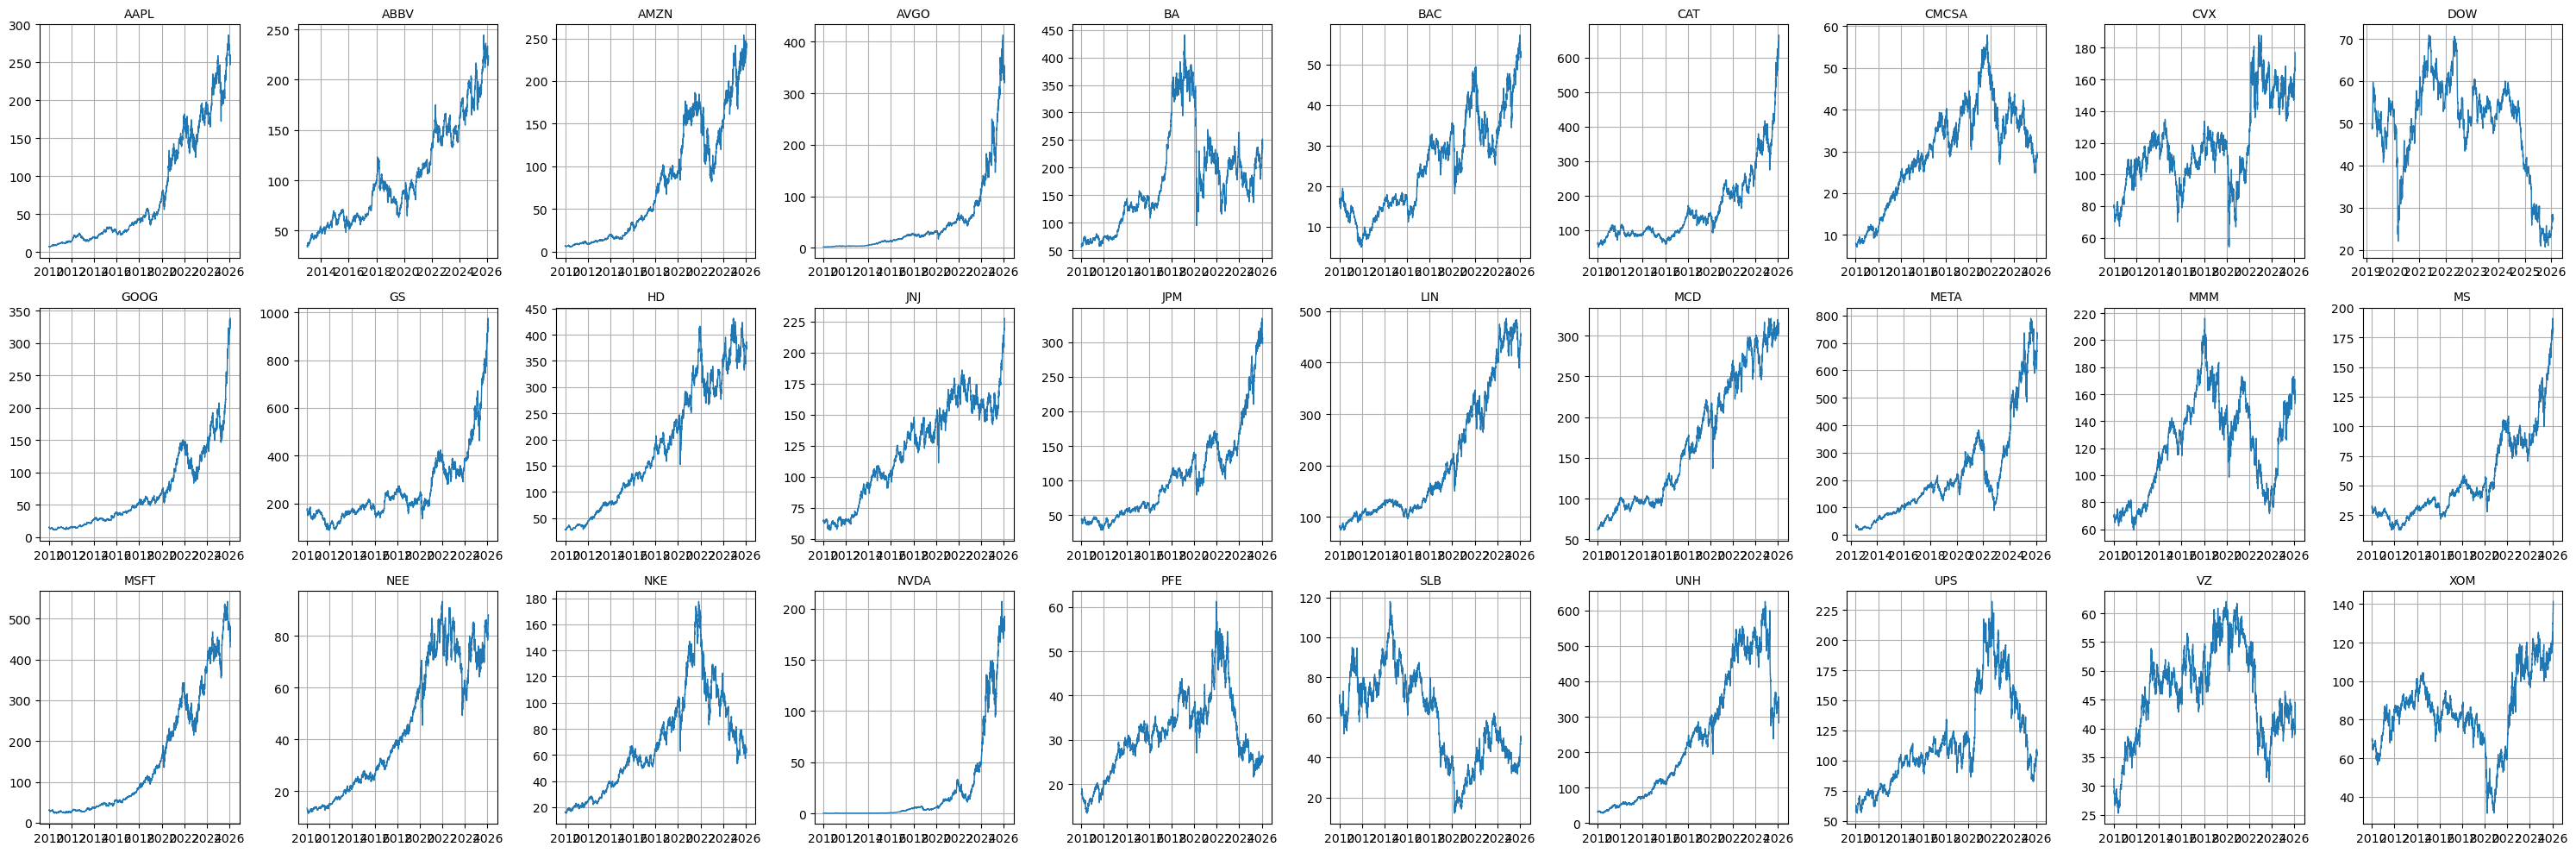

In [ ]:
# plots of closing prices for assets

tickers = list(dfs.keys())
n = len(tickers)

rows = 3
cols = 10

fig, axes = plt.subplots(rows, cols, figsize=(30, 10), sharex=False, sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    df = dfs[ticker]
    ax.plot(df['Close'], linewidth=1)
    ax.set_title(ticker, fontsize=10)
    ax.grid(True)

for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


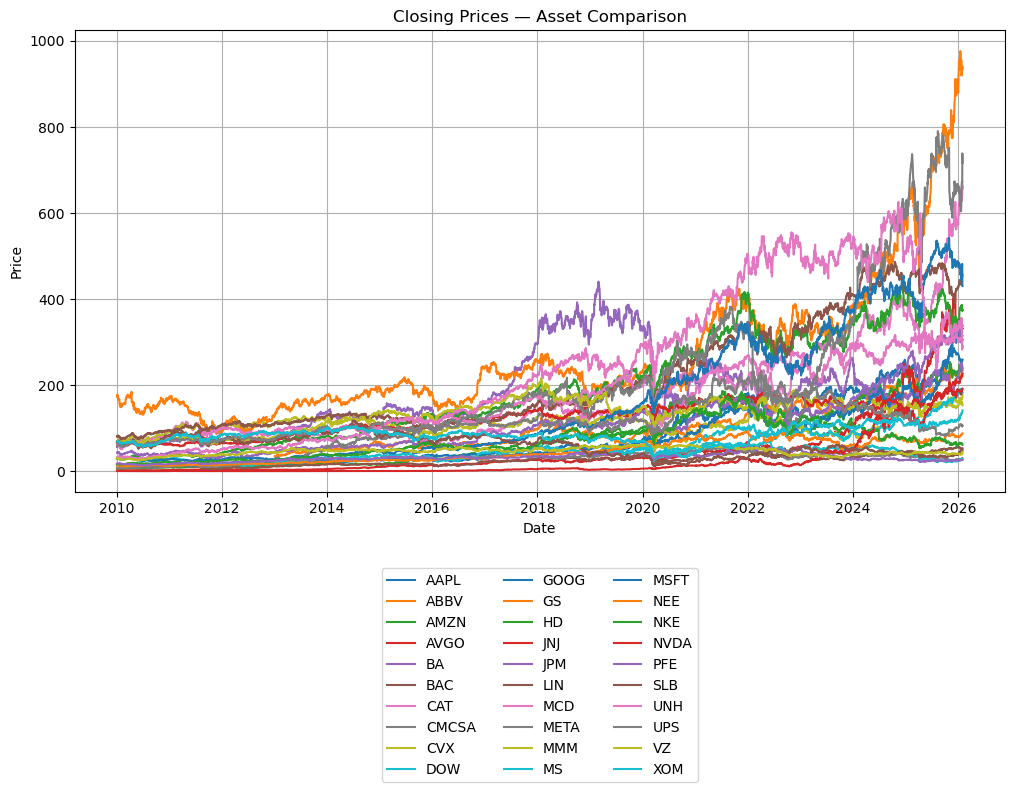

In [120]:

plt.figure(figsize=(12,6))

for ticker, df in dfs.items():
    plt.plot(df['Close'], label=ticker)

plt.title('Closing Prices — Asset Comparison')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.show()



In [122]:
# now we do the same for the S&P500

dd.download_gspc()
df = pd.read_csv("/Users/jaime/Documents/UPM/TFG/data/raw/gspc.csv", header=[0,1], index_col=0)

[*********************100%***********************]  1 of 1 completed

 Descargando GSPC

Descarga completada.


In [123]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2010-01-04,1132.989990,1132.989990,1133.869995,1116.560059,1116.560059,3991400000
2010-01-05,1136.520020,1136.520020,1136.630005,1129.660034,1132.660034,2491020000
2010-01-06,1137.140015,1137.140015,1139.189941,1133.949951,1135.709961,4972660000
2010-01-07,1141.689941,1141.689941,1142.459961,1131.319946,1136.270020,5270680000
2010-01-08,1144.979980,1144.979980,1145.390015,1136.219971,1140.520020,4389590000


In [125]:
df.isna().sum()

Price      Ticker
Adj Close  ^GSPC     0
Close      ^GSPC     0
High       ^GSPC     0
Low        ^GSPC     0
Open       ^GSPC     0
Volume     ^GSPC     0
dtype: int64

In [ ]:
expected_types = {
    'Open': 'float64',
    'High': 'float64',
    'Low': 'float64',
    'Close': 'float64',
    'Adj Close': 'float64',
    'Volume': 'int64'
}


df = df.droplevel(1,axis=1)
df.columns.name = None
for col, expected in expected_types.items():
    if df[col].dtype != expected:
            print(f"{col} incorrect dtype: {df[col].dtype} (expected: {expected})")

In [127]:
start = "2010-01-01"
end = "2026-02-01"


nyse = mcal.get_calendar('NYSE')
schedule = nyse.schedule(start_date=start, end_date=end)
expected_days = mcal.date_range(schedule, frequency='1D')
expected_days = expected_days.normalize().tz_localize(None)

df.index = pd.to_datetime(df.index, utc=True)
df_days = df.index.normalize().tz_localize(None)
missing_days = expected_days.difference(df_days)
extra_days = df_days.difference(expected_days)
duplicates = df.index[df.index.duplicated()]
print(f"GSPC: Missing days: ", missing_days)
print(f"GSPC: Extra days: ", extra_days)
print(f"GSPC: Duplicates: ",duplicates)

GSPC: Missing days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
GSPC: Extra days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
GSPC: Duplicates:  DatetimeIndex([], dtype='datetime64[ns, UTC]', name='Date', freq=None)


In [128]:
(df < 0).any()

Adj Close    False
Close        False
High         False
Low          False
Open         False
Volume       False
dtype: bool

In [129]:
df.describe().round(3)


,Adj Close,Close,High,Low,Open,Volume
count,4044.000,4044.000,4044.000,4044.000,4044.000,4.044000e+03
mean,2964.715,2964.715,2979.817,2947.215,2964.116,4.019324e+09
std,1513.422,1513.422,1520.658,1505.249,1513.304,9.972772e+08
min,1022.580,1022.580,1032.950,1010.910,1027.650,0.000000e+00
25%,1814.430,1814.430,1823.698,1805.652,1810.043,3.400402e+09
50%,2596.860,2596.860,2617.525,2577.510,2589.960,3.837220e+09
75%,4105.900,4105.900,4130.658,4073.980,4096.200,4.455315e+09
max,6978.600,6978.600,7002.280,6963.460,7002.000,1.061781e+10


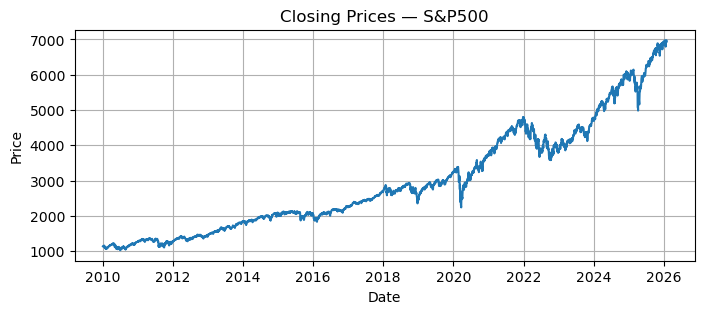

In [131]:
plt.figure(figsize=(8,3))


plt.plot(df['Close'], label="GSPC")

plt.title('Closing Prices — S&P500')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


## Complete Summary of Data Discoveries

### Data Integrity

- No null data: the 30 assets do not present missing values.  
- Correct data types: *Open, High, Low, Close, Adj Close* (`float64`) and *Volume* (`int64`).  
- Chronologically ordered dates: all assets are ordered temporally.  
- No temporal gaps: they match the NYSE trading calendar.  
- No duplicates or negative values.

### Assets Incorporated Late

- **META**: since *2012-05-18* (IPO).  
- **ABBV**: since *2013-01-02*.  
- **DOW**: since *2019-03-20*.

### Descriptive Statistics Analysis

The statistics of the 30 assets show **strong heterogeneity**:

- **High growth**: NVDA, MSFT, GOOG, META and AAPL present high average prices and very high maximums, reflecting clearly bullish trends since 2010.
- **Moderate growth**: AMZN, AVGO, JPM, UNH or LIN reach maximums between 200 and 500, with intermediate volatility.
- **Stable assets**: Energy, utilities and materials (XOM, CVX, NEE, VZ, DOW) show more contained prices and lower volatility.
- **Volumes**: Wide variability between assets, with no relevant anomalies.

### Graphs Analysis

#### Closing Price Comparison (2010–2026)
The combined graph shows:

- **Technology in strong ascent**, especially NVDA, MSFT and GOOG, with acceleration from 2016–2020.
- **Impact of the 2020 crisis**, with widespread declines and faster recoveries in technology than in energy or finance.
- **Sector divergence**: defensive sectors with flat trajectories versus growth sectors with markedly upward trends.

#### Individual Graphs
The asset-by-asset analysis shows:

- **Generalized bullish trend** in most assets since 2010.
- **Differentiated volatility** by sector: defensive assets more stable, cyclical assets more irregular.
- **Post-COVID recovery** in all assets, although at different rates.
- **Clear sector patterns**, such as late recovery in energy versus continuous growth in technology.


### Main Conclusions

1. **High quality dataset**: Perfect integrity, no additional cleaning needed.
2. **Heterogeneous behavior**: The 30 assets reveal very diverse patterns by sector, enabling regime analysis and sector rotation studies.
3. **Visible macroeconomic events**: 2020 crisis, subsequent recovery, digital transformation (technology) and inflation (energy) are clearly documented in prices.
4. **Dynamic universe necessary**: The late incorporation of META, ABBV and DOW requires a dynamic universe of stocks for backtesting analysis.

---